In [27]:
import numpy as np

class CustomMLP:
    def __init__(self, n_x, n_h, n_y=1, learning_rate=0.01, n_steps=100):
        self.n_x = n_x
        self.n_h = n_h
        self.n_y = n_y
        self.learning_rate = learning_rate
        self.n_steps = n_steps
        
        self.parameters = {}
        self.cache = {}
        self.costs = []
        
        self.__initialize_parameters()

    def __initialize_parameters(self):
        np.random.seed(42)
        self.parameters['W1'] = np.random.randn(self.n_h, self.n_x) * 0.01
        self.parameters['b1'] = np.zeros((self.n_h, 1))
        self.parameters['W2'] = np.random.randn(self.n_y, self.n_h) * 0.01
        self.parameters['b2'] = np.zeros((self.n_y, 1))

    def __sigmoid(self, Z):
        return 1 / (1 + np.exp(-1 * Z))

    def __forward_propagation(self, X):
        W1 = self.parameters['W1']
        b1 = self.parameters['b1']
        W2 = self.parameters['W2']
        b2 = self.parameters['b2']

        Z1 = np.dot(W1, X.T) + b1
        A1 = np.tanh(Z1)
        Z2 = np.dot(W2, A1) + b2
        A2 = self.__sigmoid(Z2)

        self.cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
        return A2

    def __compute_cost(self, A2, Y):
        m = A2.shape[1]
        
        epsilon = 1e-15
        
        cost = - (np.dot(np.log(A2 + epsilon), Y) + np.dot(np.log(1 - A2 + epsilon), (1 - Y))) / m
        return float(np.squeeze(cost))

    def __backward_propagation(self, X, Y):
        m = X.shape[0]
        
        W2 = self.parameters['W2']
        A1 = self.cache['A1']
        A2 = self.cache['A2']

        Y = Y.reshape(A2.shape)

        dZ2 = A2 - Y
        dW2 = (1/m) * np.dot(dZ2, A1.T)
        db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

        dZ1 = np.dot(W2.T, dZ2) * (1 - np.power(A1, 2))
        dW1 = (1/m) * np.dot(dZ1, X)
        db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

        grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
        return grads

    def __update_parameters(self, grads):
        self.parameters['W1'] -= self.learning_rate * grads['dW1']
        self.parameters['b1'] -= self.learning_rate * grads['db1']
        self.parameters['W2'] -= self.learning_rate * grads['dW2']
        self.parameters['b2'] -= self.learning_rate * grads['db2']

    def fit(self, X, Y, print_cost=True):
        for i in range(self.n_steps):
            A2 = self.__forward_propagation(X)
            cost = self.__compute_cost(A2, Y)
            grads = self.__backward_propagation(X, Y)
            self.__update_parameters(grads)
            
            self.costs.append(cost)
            
            if print_cost and i % 100 == 0:
                print(f"Cost after step {i}: {cost:.6f}")

    def predict(self, X):
        A2 = self.__forward_propagation(X)
        predicts = A2 > 0.5
        return predicts

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("BankNote_Authentication.csv")
df['var_skew_interact'] = df['variance'] * df['skewness']

X = df.drop('class', axis=1).values
y = df['class'].values.reshape(-1, 1)

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 822, Val: 275, Test: 275


In [29]:
custom_model = CustomMLP(n_x=X_train_scaled.shape[1], n_h=6, n_y=1, learning_rate=0.05, n_steps=1000)

custom_model.fit(X_train_scaled, y_train, print_cost=True)

custom_preds = custom_model.predict(X_test_scaled)

Cost after step 0: 0.693313
Cost after step 100: 0.684952
Cost after step 200: 0.585360
Cost after step 300: 0.321097
Cost after step 400: 0.169306
Cost after step 500: 0.107140
Cost after step 600: 0.078971
Cost after step 700: 0.063609
Cost after step 800: 0.054027
Cost after step 900: 0.047450


In [30]:
import torch
import torch.nn as nn
import torch.optim as optim

X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.FloatTensor(y_test)

class PyTorchMLP(nn.Module):
    def __init__(self, n_x, n_h, n_y):
        super(PyTorchMLP, self).__init__()
        self.hidden_layer = nn.Linear(n_x, n_h)
        self.output_layer = nn.Linear(n_h, n_y)
        self.tanh = nn.Tanh()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        z1 = self.hidden_layer(x)
        a1 = self.tanh(z1)
        z2 = self.output_layer(a1)
        a2 = self.sigmoid(z2)
        return a2

torch_model = PyTorchMLP(n_x=X_train_scaled.shape[1], n_h=6, n_y=1)

criterion = nn.BCELoss()
optimizer = optim.SGD(torch_model.parameters(), lr=0.05)

n_steps = 1000
for epoch in range(n_steps):
    y_pred = torch_model(X_train_t)
    loss = criterion(y_pred, y_train_t)
    
    optimizer.zero_grad()
    loss.backward()   
    optimizer.step()  
    
    if epoch % 100 == 0:
        print(f"Cost after step {epoch}: {loss.item():.6f}")

with torch.no_grad():
    torch_model.hidden_layer.weight.copy_(torch.FloatTensor(custom_model.parameters['W1']))
    torch_model.hidden_layer.bias.copy_(torch.FloatTensor(custom_model.parameters['b1'].flatten()))
    
    torch_model.output_layer.weight.copy_(torch.FloatTensor(custom_model.parameters['W2']))
    torch_model.output_layer.bias.copy_(torch.FloatTensor(custom_model.parameters['b2'].flatten()))

Cost after step 0: 0.783754
Cost after step 100: 0.604377
Cost after step 200: 0.370475
Cost after step 300: 0.207553
Cost after step 400: 0.128569
Cost after step 500: 0.091055
Cost after step 600: 0.070933
Cost after step 700: 0.058800
Cost after step 800: 0.050739
Cost after step 900: 0.044975


In [31]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluate_model(y_true, y_pred, model_name):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    
    print(f"\n{'='*40}")
    print(f"[{model_name}] TEST RESULTS")
    print(f"{'='*40}")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

evaluate_model(y_test, custom_preds, "CUSTOM MLP")
evaluate_model(y_test, torch_preds, "PYTORCH MLP")


[CUSTOM MLP] TEST RESULTS
Accuracy : 0.9891
Recall   : 1.0000
F1 Score : 0.9879

Confusion Matrix:
[[150   3]
 [  0 122]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       153
           1       0.98      1.00      0.99       122

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275


[PYTORCH MLP] TEST RESULTS
Accuracy : 0.9927
Recall   : 1.0000
F1 Score : 0.9919

Confusion Matrix:
[[151   2]
 [  0 122]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       153
           1       0.98      1.00      0.99       122

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



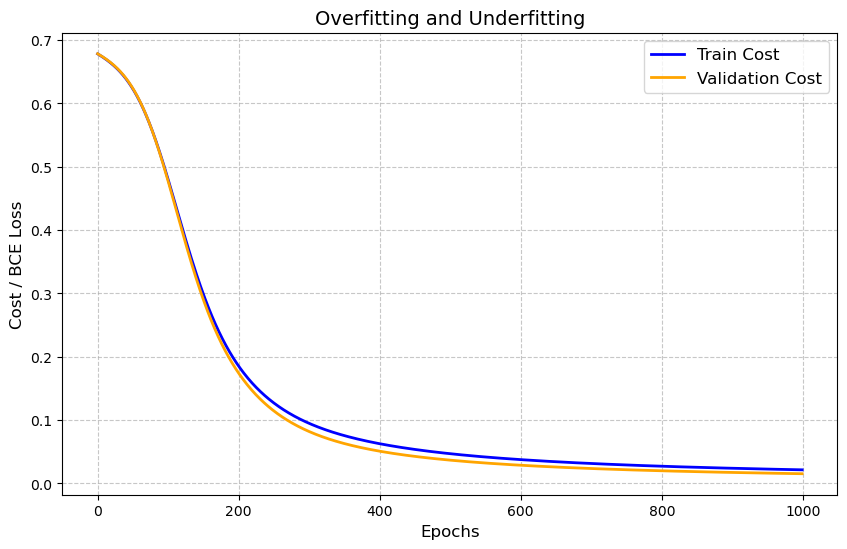


[PYTORCH MLP] TEST RESULTS
Accuracy : 0.9964
Recall   : 1.0000
F1 Score : 0.9959

Confusion Matrix:
[[152   1]
 [  0 122]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       153
           1       0.99      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train)
X_val_t = torch.FloatTensor(X_val_scaled)
y_val_t = torch.FloatTensor(y_val)

class DeepPyTorchMLP(nn.Module):
    def __init__(self, n_x, n_h1, n_h2, n_y):
        super(DeepPyTorchMLP, self).__init__()
        self.layer1 = nn.Linear(n_x, n_h1)
        self.layer2 = nn.Linear(n_h1, n_h2)
        self.layer3 = nn.Linear(n_h2, n_y)
        self.tanh = nn.Tanh()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        a1 = self.tanh(self.layer1(x))
        a2 = self.tanh(self.layer2(a1))
        a3 = self.sigmoid(self.layer3(a2))
        return a3

deep_model = DeepPyTorchMLP(n_x=X_train_scaled.shape[1], n_h1=8, n_h2=4, n_y=1)
criterion = nn.BCELoss()

optimizer = optim.SGD(deep_model.parameters(), lr=0.05, weight_decay=1e-3)

train_losses = []
val_losses = []
n_steps = 1000

for epoch in range(n_steps):
    deep_model.train()
    y_pred_train = deep_model(X_train_t)
    loss_train = criterion(y_pred_train, y_train_t)
    
    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()
    
    deep_model.eval()
    with torch.no_grad():
        y_pred_val = deep_model(X_val_t)
        loss_val = criterion(y_pred_val, y_val_t)
    
    train_losses.append(loss_train.item())
    val_losses.append(loss_val.item())

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Cost', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Cost', color='orange', linewidth=2)
plt.title('Overfitting and Underfitting', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Cost / BCE Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

deep_model.eval()
with torch.no_grad():
    X_test_t = torch.FloatTensor(X_test_scaled)
    deep_preds = (deep_model(X_test_t) > 0.5).numpy()

evaluate_model(y_test, deep_preds, "PYTORCH MLP")

In [33]:
class PyTorchMLP_BatchNorm(nn.Module):
    def __init__(self, n_x, n_h, n_y):
        super(PyTorchMLP_BatchNorm, self).__init__()
        self.layer1 = nn.Linear(n_x, n_h)
        self.bn1 = nn.BatchNorm1d(n_h)
        self.layer2 = nn.Linear(n_h, n_y)
        self.tanh = nn.Tanh()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        z1 = self.layer1(x)
        z1_bn = self.bn1(z1)
        a1 = self.tanh(z1_bn)
        z2 = self.layer2(a1)
        a2 = self.sigmoid(z2)
        return a2

bn_model = PyTorchMLP_BatchNorm(n_x=X_train_scaled.shape[1], n_h=6, n_y=1)
criterion = nn.BCELoss()
optimizer_bn = optim.SGD(bn_model.parameters(), lr=0.05)

for epoch in range(1000):
    bn_model.train()
    y_pred = bn_model(X_train_t)
    loss = criterion(y_pred, y_train_t)
    
    optimizer_bn.zero_grad()
    loss.backward()
    optimizer_bn.step()

bn_model.eval()
with torch.no_grad():
    bn_preds = (bn_model(X_test_t) > 0.5).numpy()

evaluate_model(y_test, bn_preds, "PYTORCH BATCH NORMALIZATION MLP")


[PYTORCH BATCH NORMALIZATION MLP] TEST RESULTS
Accuracy : 0.9927
Recall   : 1.0000
F1 Score : 0.9919

Confusion Matrix:
[[151   2]
 [  0 122]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       153
           1       0.98      1.00      0.99       122

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



In [34]:
from sklearn.metrics import accuracy_score

print("--- Optimal n_steps Selection ---")
target_accuracy = 0.90
optimal_n_steps = None

for step in range(100, 1001, 100):
    temp_model = CustomMLP(n_x=X_train_scaled.shape[1], n_h=6, n_y=1, learning_rate=0.05, n_steps=step)
    temp_model.fit(X_train_scaled, y_train, print_cost=False)
    
    val_preds = temp_model.predict(X_val_scaled)
    acc = accuracy_score(y_val.flatten(), val_preds.flatten())
    
    print(f"n_steps: {step:3d} -> Validation Accuracy: {acc:.4f}")
    
    if acc >= target_accuracy and optimal_n_steps is None:
        optimal_n_steps = step
        print(f">>> TARGET REACHED! Selected optimal n_steps: {optimal_n_steps}\n")
        break

--- Optimal n_steps Selection ---
n_steps: 100 -> Validation Accuracy: 0.5564
n_steps: 200 -> Validation Accuracy: 0.8145
n_steps: 300 -> Validation Accuracy: 0.9236
>>> TARGET REACHED! Selected optimal n_steps: 300



In [35]:
from torch.utils.data import TensorDataset, DataLoader

print("MINI-BATCH GRADIENT DESCENT")

batch_size = 64
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

mb_model = PyTorchMLP_BatchNorm(n_x=X_train_scaled.shape[1], n_h=6, n_y=1)
criterion_mb = nn.BCELoss()
optimizer_mb = optim.SGD(mb_model.parameters(), lr=0.05)

n_epochs = 100
mb_costs = []

for epoch in range(n_epochs):
    mb_model.train()
    epoch_loss = 0
    
    for batch_X, batch_y in train_loader:
        
        y_pred = mb_model(batch_X)
        loss = criterion_mb(y_pred, batch_y)
        
        optimizer_mb.zero_grad()
        loss.backward()
        optimizer_mb.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    mb_costs.append(avg_loss)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch} Ortalama Cost: {avg_loss:.6f}")

mb_model.eval()
with torch.no_grad():
    mb_preds = (mb_model(X_test_t) > 0.5).numpy()

evaluate_model(y_test, mb_preds, "PYTORCH MINI-BATCH & BATCH-NORM MLP")

MINI-BATCH GRADIENT DESCENT
Epoch 0 Ortalama Cost: 0.608625
Epoch 10 Ortalama Cost: 0.145018
Epoch 20 Ortalama Cost: 0.080598
Epoch 30 Ortalama Cost: 0.058690
Epoch 40 Ortalama Cost: 0.056251
Epoch 50 Ortalama Cost: 0.046285
Epoch 60 Ortalama Cost: 0.039694
Epoch 70 Ortalama Cost: 0.031309
Epoch 80 Ortalama Cost: 0.032458
Epoch 90 Ortalama Cost: 0.033693

[PYTORCH MINI-BATCH & BATCH-NORM MLP] TEST RESULTS
Accuracy : 0.9927
Recall   : 1.0000
F1 Score : 0.9919

Confusion Matrix:
[[151   2]
 [  0 122]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       153
           1       0.98      1.00      0.99       122

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



In [36]:
evaluate_model(y_test, custom_preds, "1. CUSTOM MLP")

evaluate_model(y_test, torch_preds, "2. PYTORCH MLP")

evaluate_model(y_test, deep_preds, "3. PYTORCH DEEP & REGULARIZED MLP")

evaluate_model(y_test, mb_preds, "4. PYTORCH MINI-BATCH & BATCH-NORM MLP")


[1. CUSTOM MLP] TEST RESULTS
Accuracy : 0.9891
Recall   : 1.0000
F1 Score : 0.9879

Confusion Matrix:
[[150   3]
 [  0 122]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       153
           1       0.98      1.00      0.99       122

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275


[2. PYTORCH MLP] TEST RESULTS
Accuracy : 0.9927
Recall   : 1.0000
F1 Score : 0.9919

Confusion Matrix:
[[151   2]
 [  0 122]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       153
           1       0.98      1.00      0.99       122

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275


[3. PYTORCH DEEP & REGULARIZED MLP] TEST RES